# 🦟 Mosquito Detection — Faster R-CNN (ResNet-50 backbone)

This notebook follows the two DLP course modules directly:

- **Object Recognition module** → CNN classification backbones (AlexNet / VGG / **ResNet**):
  we use a **ResNet-50** backbone (pretrained on ImageNet) to extract features.
- **Object Detection module** → region-based ConvNets (R-CNN → Fast R-CNN → **Faster R-CNN**)
  and YOLO: we use **Faster R-CNN**, which combines a CNN backbone with a Region Proposal
  Network (RPN) — the architecture the course builds up to before introducing YOLO as the
  single-shot alternative.

**Why Faster R-CNN here instead of YOLOv8:** Faster R-CNN is exactly what both decks converge
on — a ResNet backbone (Recognition module) feeding a Region Proposal Network + detection head
(Detection module). It's implemented via `torchvision.models.detection.fasterrcnn_resnet50_fpn`,
so we get a course-aligned, two-stage detector without hand-rolling the RPN/ROI-pooling math.

If you'd rather compare against the single-shot YOLO approach the course also covers, the
earlier YOLOv8 notebook is a drop-in alternative — same dataset, same submission format.


In [1]:
# --- 0. Setup ---------------------------------------------------------
!pip install -q torchmetrics opencv-python-headless tqdm

import os, glob, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as F

from torchmetrics.detection.mean_ap import MeanAveragePrecision

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| Torchvision:", torchvision.__version__)
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.10.0+cu128 | Torchvision: 0.25.0+cu128
Device: cuda
GPU: Tesla T4


In [2]:
# --- 1. Config — EDIT PATHS TO MATCH YOUR SETUP ------------------------
class CFG:
    DATA_ROOT   = "/kaggle/input/competitions/dlp-26t2-week10-assignment/final_dlp_data/final_dlp_data"  # <-- EDIT ME
    TRAIN_IMG   = f"{DATA_ROOT}/train/images"
    TRAIN_LBL   = f"{DATA_ROOT}/train/labels"
    TEST_IMG    = f"{DATA_ROOT}/test/images"
    SAMPLE_SUB  = "/kaggle/input/competitions/dlp-26t2-week10-assignment/sample_submission.csv"  # <-- EDIT ME

    CLASSES = ["aegypti", "albopictus", "anopheles", "culex", "culiseta", "japonicus/koreicus"]
    NUM_CLASSES = len(CLASSES)          # background class (0) is added automatically by torchvision

    VAL_FRACTION = 0.15
    IMG_SIZE     = 800       # shorter-side resize for Faster R-CNN (its own internal transform also rescales)
    BATCH        = 4         # Faster R-CNN is much more memory-hungry than YOLO -- keep this small
    EPOCHS       = 10
    LR           = 0.005
    WEIGHT_DECAY = 0.0005
    SCORE_THRESH = 0.5       # inference confidence threshold, tuned in Section 8
    NMS_IOU      = 0.5

    APPLY_LOW_LIGHT_ENHANCEMENT = True
    OUT_DIR = "/kaggle/working"

os.makedirs(CFG.OUT_DIR, exist_ok=True)
for name, p in [("TRAIN_IMG", CFG.TRAIN_IMG), ("TRAIN_LBL", CFG.TRAIN_LBL),
                 ("TEST_IMG", CFG.TEST_IMG), ("SAMPLE_SUB", CFG.SAMPLE_SUB)]:
    print(name, "->", p, "| exists:", os.path.exists(p))


TRAIN_IMG -> /kaggle/input/competitions/dlp-26t2-week10-assignment/final_dlp_data/final_dlp_data/train/images | exists: True
TRAIN_LBL -> /kaggle/input/competitions/dlp-26t2-week10-assignment/final_dlp_data/final_dlp_data/train/labels | exists: True
TEST_IMG -> /kaggle/input/competitions/dlp-26t2-week10-assignment/final_dlp_data/final_dlp_data/test/images | exists: True
SAMPLE_SUB -> /kaggle/input/competitions/dlp-26t2-week10-assignment/sample_submission.csv | exists: True


## 2. Low-light enhancement (same CLAHE + gamma approach as before)

Applied only to genuinely dark images, consistently at both train and inference time.


In [3]:
def enhance_low_light(img, brightness_thresh=80, clip_limit=2.5, gamma=1.6):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_v = hsv[:, :, 2].mean()
    if mean_v >= brightness_thresh:
        return img
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    g = gamma if mean_v < 50 else gamma * 0.7
    inv_gamma = 1.0 / g
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img, table)


## 3. Dataset

`torchvision`'s detection models expect **absolute pixel-coordinate `[x1, y1, x2, y2]` boxes**,
not YOLO's normalized `[xc, yc, w, h]` — this dataset class does that conversion.
Class label `0` is reserved for background by torchvision, so our 6 classes become `1..6`.


In [4]:
def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = (xc - w / 2) * img_w
    y1 = (yc - h / 2) * img_h
    x2 = (xc + w / 2) * img_w
    y2 = (yc + h / 2) * img_h
    return [x1, y1, x2, y2]

class MosquitoDataset(Dataset):
    def __init__(self, image_paths, label_dir, classes, enhance=True, train=True):
        self.image_paths = image_paths
        self.label_dir = label_dir
        self.classes = classes
        self.enhance = enhance
        self.train = train

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_h, img_w = img.shape[:2]

        if self.enhance:
            bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            bgr = enhance_low_light(bgr)
            img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        stem = Path(img_path).stem
        label_path = os.path.join(self.label_dir, stem + ".txt") if self.label_dir else None

        boxes, labels = [], []
        if label_path and os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id, xc, yc, w, h = map(float, parts[:5])
                    x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, img_w, img_h)
                    # guard against degenerate boxes
                    if x2 <= x1 or y2 <= y1:
                        continue
                    boxes.append([x1, y1, x2, y2])
                    labels.append(int(cls_id) + 1)  # +1: torchvision reserves 0 for background

        boxes_t = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
        labels_t = torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx]),
            "area": (boxes_t[:, 2] - boxes_t[:, 0]) * (boxes_t[:, 3] - boxes_t[:, 1]) if len(boxes) else torch.zeros((0,)),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
        }

        img_tensor = F.to_tensor(img)  # torchvision detection models normalize internally
        return img_tensor, target, img_path

def collate_fn(batch):
    return tuple(zip(*batch))


## 4. Train/val split + DataLoaders

In [5]:
all_train_images = sorted(glob.glob(os.path.join(CFG.TRAIN_IMG, "*")))
stems_with_labels = [p for p in all_train_images
                      if os.path.exists(os.path.join(CFG.TRAIN_LBL, Path(p).stem + ".txt"))]
print(f"Train images with labels: {len(stems_with_labels)} / {len(all_train_images)}")

random.seed(SEED)
random.shuffle(stems_with_labels)
n_val = int(len(stems_with_labels) * CFG.VAL_FRACTION)
val_images = stems_with_labels[:n_val]
train_images = stems_with_labels[n_val:]
print(f"Train: {len(train_images)} | Val: {len(val_images)}")

train_ds = MosquitoDataset(train_images, CFG.TRAIN_LBL, CFG.CLASSES, enhance=CFG.APPLY_LOW_LIGHT_ENHANCEMENT, train=True)
val_ds   = MosquitoDataset(val_images,   CFG.TRAIN_LBL, CFG.CLASSES, enhance=CFG.APPLY_LOW_LIGHT_ENHANCEMENT, train=False)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH, shuffle=True,  num_workers=2, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH, shuffle=False, num_workers=2, collate_fn=collate_fn)


Train images with labels: 7500 / 7500
Train: 6375 | Val: 1125


## 5. Smoke test — sanity check the pipeline on a handful of batches before full training

Faster R-CNN training is much slower per-image than YOLO, so catching bugs here saves real time.


In [6]:
def smoke_test():
    t0 = time.time()
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, CFG.NUM_CLASSES + 1)
    model.to(DEVICE)
    model.train()

    optimizer = torch.optim.SGD(model.parameters(), lr=CFG.LR, momentum=0.9, weight_decay=CFG.WEIGHT_DECAY)

    n_batches = min(3, len(train_loader))
    it = iter(train_loader)
    losses_seen = []
    for i in range(n_batches):
        imgs, targets, _ = next(it)
        imgs = [img.to(DEVICE) for img in imgs]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses_seen.append(float(loss.item()))
        print(f"batch {i}: loss={loss.item():.4f}  ({ {k: round(float(v), 3) for k, v in loss_dict.items()} })")

    assert all(np.isfinite(losses_seen)), "Non-finite loss encountered -- check label/box conversion."
    print(f"\nSmoke test passed in {time.time()-t0:.1f}s. Losses are finite and decreasing-ish across batches.")

    # Quick estimate of full-epoch time
    per_batch = (time.time() - t0) / n_batches
    est_epoch_min = per_batch * len(train_loader) / 60
    est_total_hr = est_epoch_min * CFG.EPOCHS / 60
    print(f"Rough estimate: ~{est_epoch_min:.1f} min/epoch -> ~{est_total_hr:.2f} hours for {CFG.EPOCHS} epochs.")
    print("If that's more than your time budget, lower CFG.EPOCHS or CFG.BATCH/CFG.IMG_SIZE before Section 6.")

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

smoke_test()


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 192MB/s]
/tmp/ipykernel_23/2729334653.py:23: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f"batch {i}: loss={loss.item():.4f}  ({ {k: round(float(v), 3) for k, v in loss_dict.items()} })")


batch 0: loss=2.4566  ({'loss_classifier': 2.303, 'loss_box_reg': 0.14, 'loss_objectness': 0.009, 'loss_rpn_box_reg': 0.005})
batch 1: loss=0.9252  ({'loss_classifier': 0.732, 'loss_box_reg': 0.179, 'loss_objectness': 0.004, 'loss_rpn_box_reg': 0.01})
batch 2: loss=0.3288  ({'loss_classifier': 0.154, 'loss_box_reg': 0.079, 'loss_objectness': 0.088, 'loss_rpn_box_reg': 0.007})

Smoke test passed in 11.1s. Losses are finite and decreasing-ish across batches.
Rough estimate: ~98.6 min/epoch -> ~16.43 hours for 10 epochs.
If that's more than your time budget, lower CFG.EPOCHS or CFG.BATCH/CFG.IMG_SIZE before Section 6.


## 6. Build the model (ResNet-50 + FPN backbone, Faster R-CNN head)

`fasterrcnn_resnet50_fpn` ships pretrained on COCO (backbone pretrained on ImageNet, per the
Object Recognition module's ResNet coverage). We replace only the final box-classification
head so it predicts our 6 mosquito classes (+ background) instead of COCO's 80.


In [7]:
def build_model(num_classes_with_bg):
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes_with_bg)
    return model

model = build_model(CFG.NUM_CLASSES + 1)
model.to(DEVICE)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=CFG.LR, momentum=0.9, weight_decay=CFG.WEIGHT_DECAY)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=int(CFG.EPOCHS * 0.6), gamma=0.1)

print(model.roi_heads.box_predictor)


FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=7, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=28, bias=True)
)


## 7. Training loop

Standard torchvision detection training loop (no external `engine.py` dependency needed —
written out explicitly here so it's easy to follow/modify). Tracks train loss per epoch and
validation mAP via `torchmetrics`, and keeps the best-mAP checkpoint.


In [8]:
def evaluate_map(model, data_loader, device):
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy", class_metrics=False)
    with torch.no_grad():
        for imgs, targets, _ in data_loader:
            imgs = [img.to(device) for img in imgs]
            preds = model(imgs)
            preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in preds]
            targets_cpu = [{"boxes": t["boxes"], "labels": t["labels"]} for t in targets]
            metric.update(preds_cpu, targets_cpu)
    result = metric.compute()
    model.train()
    return result

best_map = -1.0
history = []
BEST_PATH = os.path.join(CFG.OUT_DIR, "fasterrcnn_best.pt")

for epoch in range(CFG.EPOCHS):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CFG.EPOCHS}")
    for imgs, targets, _ in pbar:
        imgs = [img.to(DEVICE) for img in imgs]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += float(loss.item())
        pbar.set_postfix(loss=float(loss.item()))

    lr_scheduler.step()
    avg_loss = epoch_loss / len(train_loader)

    val_metrics = evaluate_map(model, val_loader, DEVICE)
    map50_95 = float(val_metrics["map"])
    map50 = float(val_metrics["map_50"])

    print(f"Epoch {epoch+1}: train_loss={avg_loss:.4f} | val mAP50-95={map50_95:.4f} | val mAP50={map50:.4f} "
          f"| time={time.time()-t0:.1f}s")
    history.append({"epoch": epoch + 1, "train_loss": avg_loss, "map50_95": map50_95, "map50": map50})

    if map50_95 > best_map:
        best_map = map50_95
        torch.save(model.state_dict(), BEST_PATH)
        print(f"  -> New best mAP50-95={best_map:.4f}, saved to {BEST_PATH}")

history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(CFG.OUT_DIR, "training_history.csv"), index=False)
print("\nTraining complete. Best val mAP50-95:", best_map)


Epoch 1/10:   0%|          | 0/1594 [00:00<?, ?it/s]

Epoch 1: train_loss=0.1185 | val mAP50-95=0.2794 | val mAP50=0.3904 | time=2915.2s
  -> New best mAP50-95=0.2794, saved to /kaggle/working/fasterrcnn_best.pt


Epoch 2/10:   0%|          | 0/1594 [00:00<?, ?it/s]

Epoch 2: train_loss=0.0809 | val mAP50-95=0.2300 | val mAP50=0.3023 | time=2959.3s


Epoch 3/10:   0%|          | 0/1594 [00:00<?, ?it/s]

...

Epoch 9/10:   0%|          | 0/1594 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f6427998cc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f6427998cc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 9: train_loss=0.0357 | val mAP50-95=0.3808 | val mAP50=0.4765 | time=2990.8s
  -> New best mAP50-95=0.3808, saved to /kaggle/working/fasterrcnn_best.pt


Epoch 10/10:   0%|          | 0/1594 [00:00<?, ?it/s]

Epoch 10: train_loss=0.0341 | val mAP50-95=0.3834 | val mAP50=0.4775 | time=2986.5s
  -> New best mAP50-95=0.3834, saved to /kaggle/working/fasterrcnn_best.pt

Training complete. Best val mAP50-95: 0.3833850026130676


## 8. Plot training curves and pick a score threshold

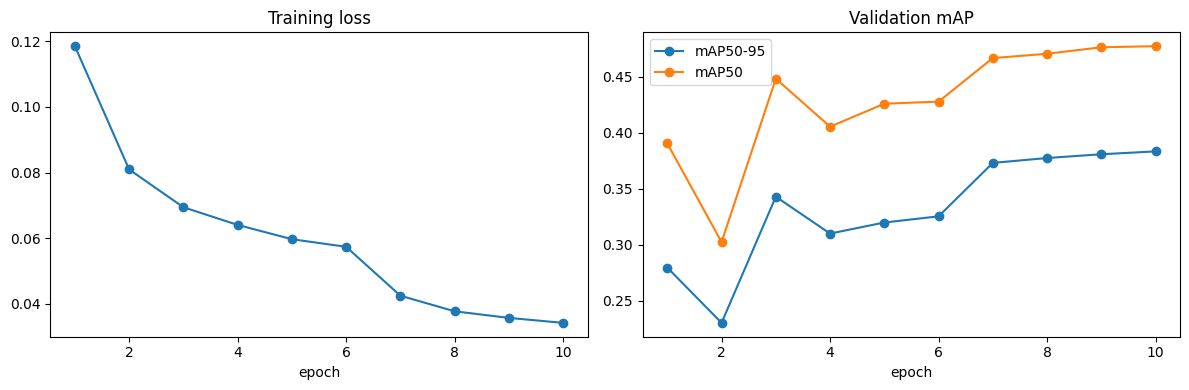

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o")
axes[0].set_title("Training loss"); axes[0].set_xlabel("epoch")

axes[1].plot(history_df["epoch"], history_df["map50_95"], marker="o", label="mAP50-95")
axes[1].plot(history_df["epoch"], history_df["map50"], marker="o", label="mAP50")
axes[1].set_title("Validation mAP"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()


In [10]:
# Load best checkpoint before threshold tuning / inference
model = build_model(CFG.NUM_CLASSES + 1)
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()
print("Loaded best checkpoint:", BEST_PATH)

# Score threshold sweep on val set: pick the score cutoff that maximizes mAP50
score_candidates = [0.3, 0.4, 0.5, 0.6, 0.7]
sweep_rows = []
with torch.no_grad():
    for sc in score_candidates:
        metric = MeanAveragePrecision(box_format="xyxy")
        for imgs, targets, _ in val_loader:
            imgs_dev = [img.to(DEVICE) for img in imgs]
            preds = model(imgs_dev)
            filtered_preds = []
            for p in preds:
                keep = p["scores"] >= sc
                filtered_preds.append({k: v[keep].cpu() for k, v in p.items()})
            targets_cpu = [{"boxes": t["boxes"], "labels": t["labels"]} for t in targets]
            metric.update(filtered_preds, targets_cpu)
        res = metric.compute()
        sweep_rows.append({"score_thresh": sc, "map50": float(res["map_50"]), "map50_95": float(res["map"])})

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)
CFG.SCORE_THRESH = float(sweep_df.loc[sweep_df["map50"].idxmax(), "score_thresh"])
print(f"\nSelected CFG.SCORE_THRESH = {CFG.SCORE_THRESH}")


Loaded best checkpoint: /kaggle/working/fasterrcnn_best.pt


,score_thresh,map50,map50_95
0,0.3,0.449080,0.361366
1,0.4,0.436316,0.351969
2,0.5,0.418808,0.339279
3,0.6,0.401239,0.324801
4,0.7,0.379297,0.307242



Selected CFG.SCORE_THRESH = 0.3


## 9. Visualize predictions on a few validation images

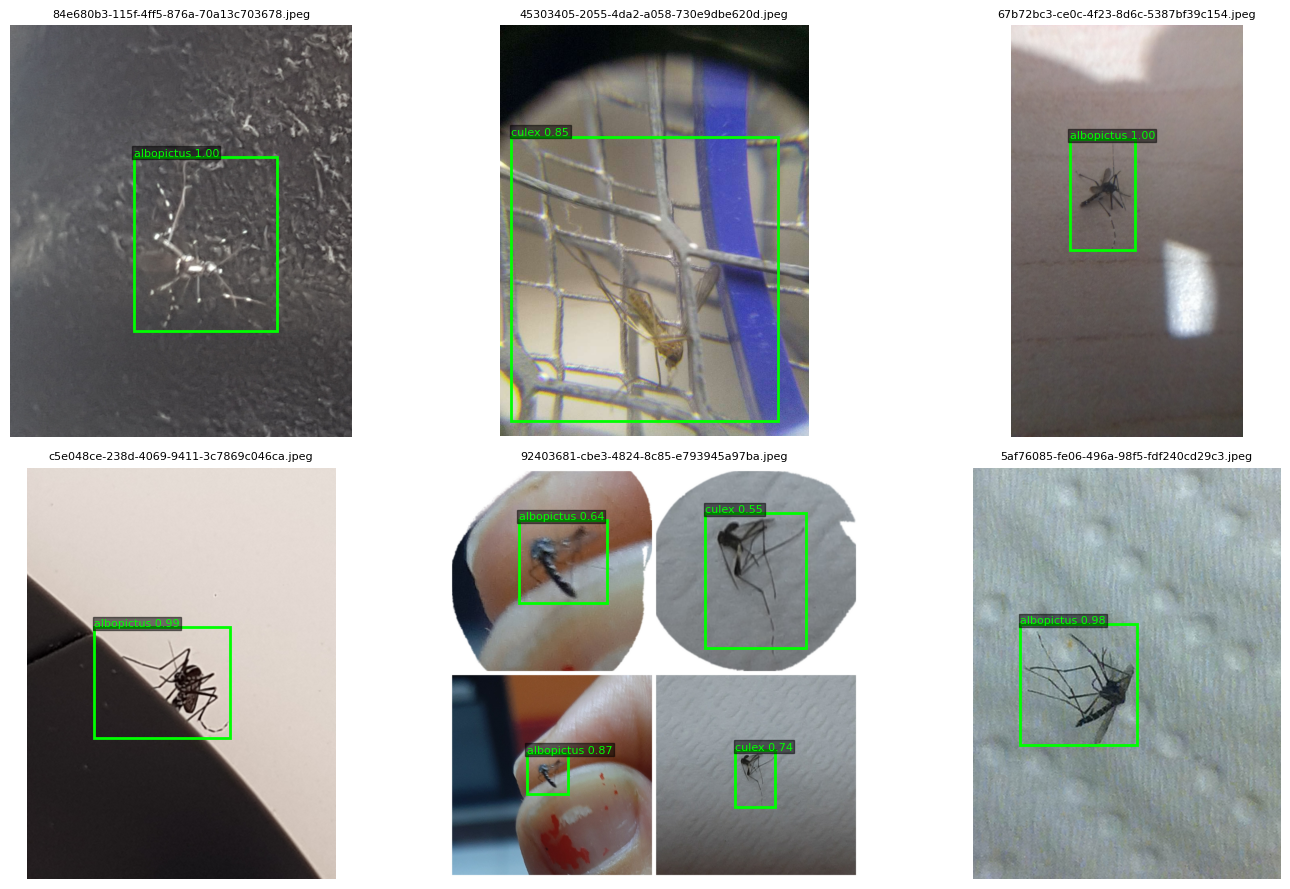

In [11]:
def draw_boxes_on_ax(img_tensor, boxes, labels, scores, ax, class_names, score_thresh=0.0):
    img = img_tensor.permute(1, 2, 0).numpy()
    ax.imshow(img)
    for box, label, score in zip(boxes, labels, scores):
        if score < score_thresh:
            continue
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        cls_name = class_names[int(label) - 1] if 1 <= int(label) <= len(class_names) else "?"
        ax.text(x1, max(y1 - 5, 0), f"{cls_name} {score:.2f}", color="lime", fontsize=8,
                bbox=dict(facecolor="black", alpha=0.5, pad=1))
    ax.axis("off")

model.eval()
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
sample_idx = random.sample(range(len(val_ds)), min(6, len(val_ds)))
with torch.no_grad():
    for ax, idx in zip(axes.ravel(), sample_idx):
        img_tensor, target, img_path = val_ds[idx]
        pred = model([img_tensor.to(DEVICE)])[0]
        draw_boxes_on_ax(img_tensor, pred["boxes"].cpu().numpy(), pred["labels"].cpu().numpy(),
                          pred["scores"].cpu().numpy(), ax, CFG.CLASSES, score_thresh=CFG.SCORE_THRESH)
        ax.set_title(Path(img_path).name, fontsize=8)
plt.tight_layout(); plt.show()


## 10. Full test-set inference + submission

Matches the confirmed-correct format: `id, ImageID, LabelName, Conf, xcenter, ycenter,
bbx_width, bbx_height`, one row per image (highest-scoring detection kept per image), with
boxes converted back from absolute pixels to normalized `xcenter/ycenter/width/height`.


In [12]:
test_images = sorted(glob.glob(os.path.join(CFG.TEST_IMG, "*")))
print(f"Found {len(test_images)} test images.")

test_ds = MosquitoDataset(test_images, label_dir=None, classes=CFG.CLASSES,
                           enhance=CFG.APPLY_LOW_LIGHT_ENHANCEMENT, train=False)

id_to_name = dict(enumerate(CFG.CLASSES))  # 0-indexed name lookup; predicted label is 1-indexed
image_filename_map = {Path(p).stem: Path(p).name for p in test_images}

rows = []
model.eval()
with torch.no_grad():
    for i in tqdm(range(len(test_ds)), desc="Predicting test set"):
        img_tensor, _, img_path = test_ds[i]
        img_h, img_w = img_tensor.shape[1], img_tensor.shape[2]
        stem = Path(img_path).stem

        pred = model([img_tensor.to(DEVICE)])[0]
        boxes = pred["boxes"].cpu().numpy()
        scores = pred["scores"].cpu().numpy()
        labels = pred["labels"].cpu().numpy()

        keep = scores >= CFG.SCORE_THRESH
        boxes, scores, labels = boxes[keep], scores[keep], labels[keep]

        if len(boxes) == 0:
            rows.append({"image_id": stem, "class_id": None, "confidence": None,
                         "xcenter": None, "ycenter": None, "bbx_width": None, "bbx_height": None})
            continue

        # keep only the highest-confidence detection for this image
        best_i = int(np.argmax(scores))
        x1, y1, x2, y2 = boxes[best_i]
        cls_id = int(labels[best_i]) - 1  # back to 0-indexed class id
        conf = float(scores[best_i])

        xc = ((x1 + x2) / 2) / img_w
        yc = ((y1 + y2) / 2) / img_h
        bw = (x2 - x1) / img_w
        bh = (y2 - y1) / img_h

        rows.append({"image_id": stem, "class_id": cls_id, "confidence": conf,
                     "xcenter": xc, "ycenter": yc, "bbx_width": bw, "bbx_height": bh})

pred_df = pd.DataFrame(rows)
n_real = pred_df["class_id"].notna().sum()
print(f"Real detections: {n_real} / {len(test_images)} images")
display(pred_df.head())


Found 525 test images.


Predicting test set:   0%|          | 0/525 [00:00<?, ?it/s]

Real detections: 522 / 525 images


,image_id,class_id,confidence,xcenter,ycenter,bbx_width,bbx_height
0,0031063e-716a-4080-934c-77598dc8de72,3.0,0.969828,0.493582,0.559151,0.146438,0.119174
1,00fbfad7-9722-4581-831c-79faa576ea7f,1.0,0.976854,0.484365,0.610289,0.192533,0.144067
2,02043b0e-3d7d-4ca4-a36f-4bf97c344264,3.0,0.995429,0.582667,0.462683,0.536210,0.434738
3,0365513c-8f00-44f3-abd0-1fadde81c602,3.0,0.997591,0.433144,0.748470,0.412781,0.198472
4,0365d78b-2064-4d54-b15c-994d1950479a,1.0,0.991608,0.234245,0.209466,0.129708,0.103229


In [13]:
# Fill images with zero detections with a low-confidence default box, and finalize columns
all_ids = pd.DataFrame({"image_id": list(image_filename_map.keys())})
submission_df = all_ids.merge(pred_df, on="image_id", how="left")

submission_df["class_id"] = submission_df["class_id"].fillna(0).astype(int)
submission_df["confidence"] = submission_df["confidence"].fillna(0.0)
submission_df[["xcenter", "ycenter"]] = submission_df[["xcenter", "ycenter"]].fillna(0.5)
submission_df[["bbx_width", "bbx_height"]] = submission_df[["bbx_width", "bbx_height"]].fillna(0.1)

submission_df["ImageID"] = submission_df["image_id"].map(image_filename_map)
submission_df["LabelName"] = submission_df["class_id"].map(id_to_name)
submission_df = submission_df.rename(columns={"confidence": "Conf"})
# submission_df.insert(0, "id", range(len(submission_df)))
# submission_df = submission_df[["id", "ImageID", "LabelName", "Conf", "xcenter", "ycenter", "bbx_width", "bbx_height"]]

# print("Class distribution in submission:")
# print(submission_df["LabelName"].value_counts())
# display(submission_df.head(10))
submission_df.insert(0, "id", range(len(submission_df)))
submission_df = submission_df[["id", "ImageID", "LabelName", "Conf", "xcenter", "ycenter", "bbx_width", "bbx_height"]]

# --- Row-order fix: match sample_submission.csv exactly before saving ---
sample_sub = pd.read_csv(CFG.SAMPLE_SUB)
submission_df = (
    submission_df.set_index("ImageID")
                  .loc[sample_sub["ImageID"]]
                  .reset_index()
)
submission_df["id"] = range(len(submission_df))
submission_df = submission_df[["id", "ImageID", "LabelName", "Conf", "xcenter", "ycenter", "bbx_width", "bbx_height"]]

order_matches = (sample_sub["ImageID"].values == submission_df["ImageID"].values).all()
print("Row order matches sample_submission.csv:", order_matches)
assert order_matches, "Row order mismatch -- check for duplicate/missing ImageIDs."
# -------------------------------------------------------------------------

print("Class distribution in submission:")
print(submission_df["LabelName"].value_counts())
display(submission_df.head(10))

Row order matches sample_submission.csv: True
Class distribution in submission:
LabelName
albopictus            245
culex                 232
culiseta               32
japonicus/koreicus     13
aegypti                 3
Name: count, dtype: int64


,id,ImageID,LabelName,Conf,xcenter,ycenter,bbx_width,bbx_height
0,0,16dbbc39-fcb6-498e-963f-d3807fcc3cec.jpeg,albopictus,0.997887,0.432793,0.452106,0.131856,0.112366
1,1,7daa68bd-928b-4b43-850f-4626f16d2c14.jpeg,albopictus,0.998192,0.500926,0.557946,0.441987,0.314622
2,2,bb0986d9-fa04-40a5-8de2-c54045537e17.jpeg,albopictus,0.974578,0.359215,0.471097,0.115266,0.175692
3,3,11924d04-69fe-469d-8d1c-119bc0f0b94f.jpeg,culex,0.908235,0.643616,0.638180,0.712768,0.625595
4,4,db4ade79-fce4-4d77-a8fa-36b9e77dfd08.jpeg,culex,0.971863,0.615170,0.533788,0.205655,0.112412
5,5,e4b45fc6-2c07-48b5-a2e2-89a7269a5215.jpeg,culex,0.920882,0.361892,0.465402,0.086229,0.131276
6,6,ed1bdf6c-31ac-4e75-be11-8ff41bae2423.jpeg,albopictus,0.990476,0.485337,0.581867,0.386817,0.257430
7,7,373cb153-8553-44cd-bffb-dc39bdf9adf6.jpeg,albopictus,0.994614,0.521334,0.524297,0.151624,0.094004
8,8,a049be38-1760-42f8-9f37-a7d7b8dde450.jpeg,japonicus/koreicus,0.501663,0.459370,0.500208,0.212997,0.160030
9,9,120dbc2e-d2f2-4e7f-969c-49055306eece.jpeg,culex,0.926340,0.639995,0.562183,0.593623,0.283340


## 11. Validate against `sample_submission.csv` before saving

In [14]:
if os.path.exists(CFG.SAMPLE_SUB):
    sample_sub = pd.read_csv(CFG.SAMPLE_SUB)
    print("Expected columns:", sample_sub.columns.tolist())
    print("Got columns     :", submission_df.columns.tolist())
    print("Row count match :", len(submission_df) == len(sample_sub),
          f"(mine={len(submission_df)}, expected={len(sample_sub)})")

    expected_exts = set(sample_sub["ImageID"].astype(str).str.split(".").str[-1])
    got_exts = set(Path(p).suffix.lstrip(".") for p in test_images)
    print("Expected extensions:", expected_exts, "| Found:", got_exts)

    missing = set(sample_sub["ImageID"]) - set(submission_df["ImageID"])
    extra = set(submission_df["ImageID"]) - set(sample_sub["ImageID"])
    print("Missing ImageIDs:", len(missing), "| Extra ImageIDs:", len(extra))

    bad_labels = set(submission_df["LabelName"]) - set(CFG.CLASSES)
    print("Unexpected LabelName values:", bad_labels if bad_labels else "none -- all valid")

    print("\nValue ranges (should all be within [0, 1]):")
    print(submission_df[["xcenter", "ycenter", "bbx_width", "bbx_height"]].describe())
else:
    print(f"sample_submission.csv not found at {CFG.SAMPLE_SUB}")


Expected columns: ['id', 'ImageID', 'LabelName', 'Conf', 'xcenter', 'ycenter', 'bbx_width', 'bbx_height']
Got columns     : ['id', 'ImageID', 'LabelName', 'Conf', 'xcenter', 'ycenter', 'bbx_width', 'bbx_height']
Row count match : True (mine=525, expected=525)
Expected extensions: {'jpeg'} | Found: {'jpeg'}
Missing ImageIDs: 0 | Extra ImageIDs: 0
Unexpected LabelName values: none -- all valid

Value ranges (should all be within [0, 1]):
          xcenter     ycenter   bbx_width  bbx_height
count  525.000000  525.000000  525.000000  525.000000
mean     0.491991    0.501161    0.338828    0.291224
std      0.081473    0.095872    0.199508    0.188804
min      0.180011    0.099982    0.058109    0.052232
25%      0.444268    0.446653    0.179383    0.148153
50%      0.494297    0.501815    0.278206    0.236310
75%      0.537990    0.554256    0.459110    0.381048
max      0.809062    0.823749    1.000000    1.000000


In [15]:
out_path = os.path.join(CFG.OUT_DIR, "submission.csv")
submission_df.to_csv("submission.csv", index=False)
print("Saved:", out_path)
print(f"Total rows: {len(submission_df)}")


Saved: /kaggle/working/submission.csv
Total rows: 525


## 12. Notes tying this back to the course material

- **Object Recognition module**: the ResNet-50 backbone here is exactly the "case study" CNN
  architecture (AlexNet → VGG → ResNet) that module builds up to, used here as a pretrained
  ImageNet feature extractor rather than trained from scratch.
- **Object Detection module**: Faster R-CNN is the endpoint of that module's R-CNN → Fast R-CNN
  → Faster R-CNN progression — a Region Proposal Network replaces the external/selective-search
  proposals of R-CNN/Fast R-CNN, sharing convolutional features with the detection head for
  speed. The module's next topic, YOLO, is a single-shot alternative (dense grid prediction,
  no explicit region-proposal stage) — that's implemented in the separate YOLOv8 notebook if
  you want a side-by-side comparison of the two-stage vs. single-shot approaches taught here.
- **Ideas to improve further, in the same spirit as the course's progression**: swap the
  backbone for a deeper ResNet (ResNet-101), add Feature Pyramid Network tuning for the small
  mosquito objects, or compare directly against the YOLO notebook's mAP on the same val split.
